In [16]:
#pip install trimesh numpy
#pip install numpy numpy-stl shapely matplotlib

SyntaxError: invalid syntax (942646123.py, line 2)

## TESTING CLAUDE CODE

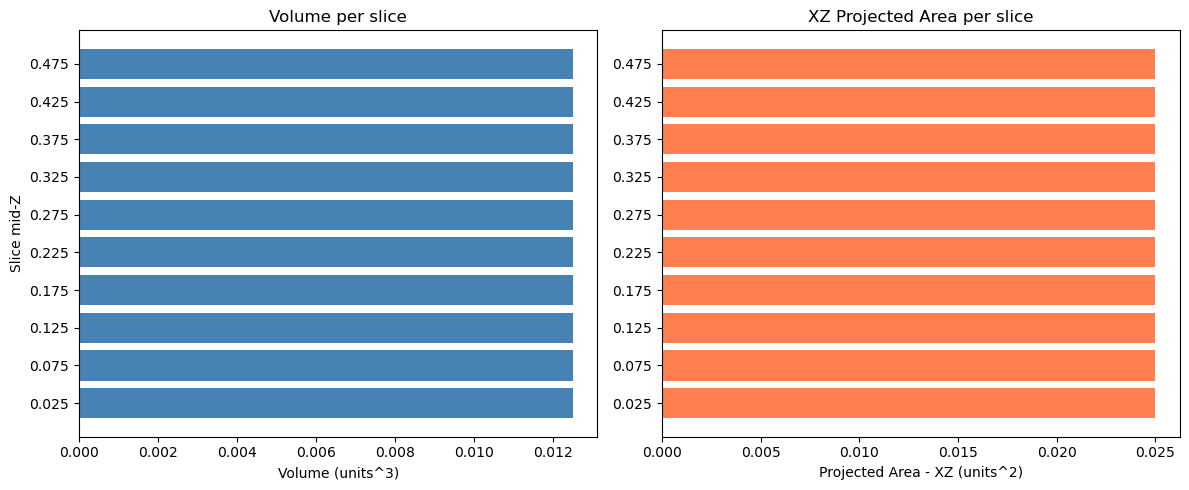

In [2]:
from reef_slice_analysis import analyse_reef_slices

results = analyse_reef_slices("test_cube.stl", n=10, plot=True)
# Each result dict has: slice_index, z_min, z_max, volume, projected_area_xz

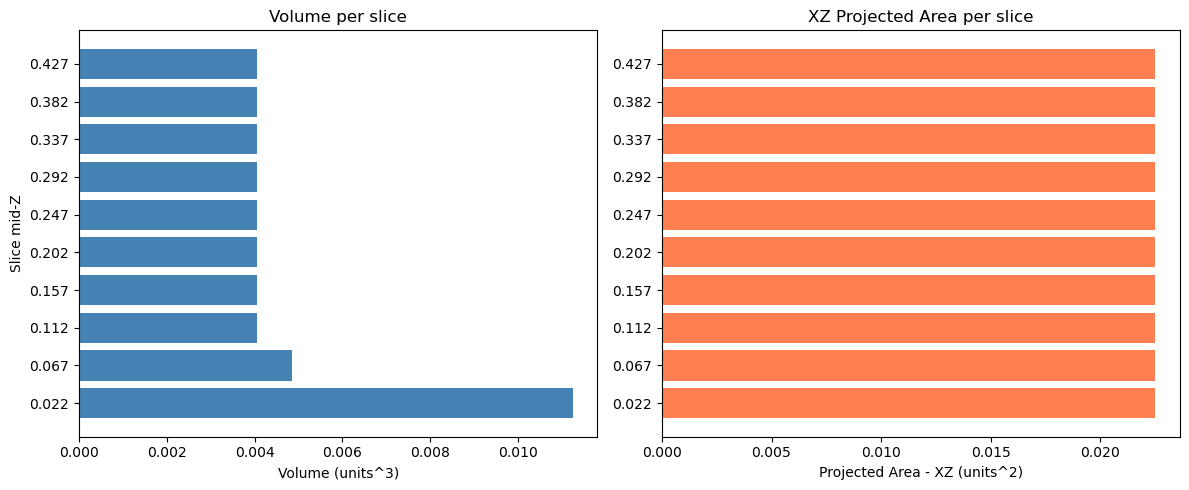

In [10]:
results = analyse_reef_slices("test_box.stl", n=10, plot=True)

## TRY WITH ACTUAL DESIGN

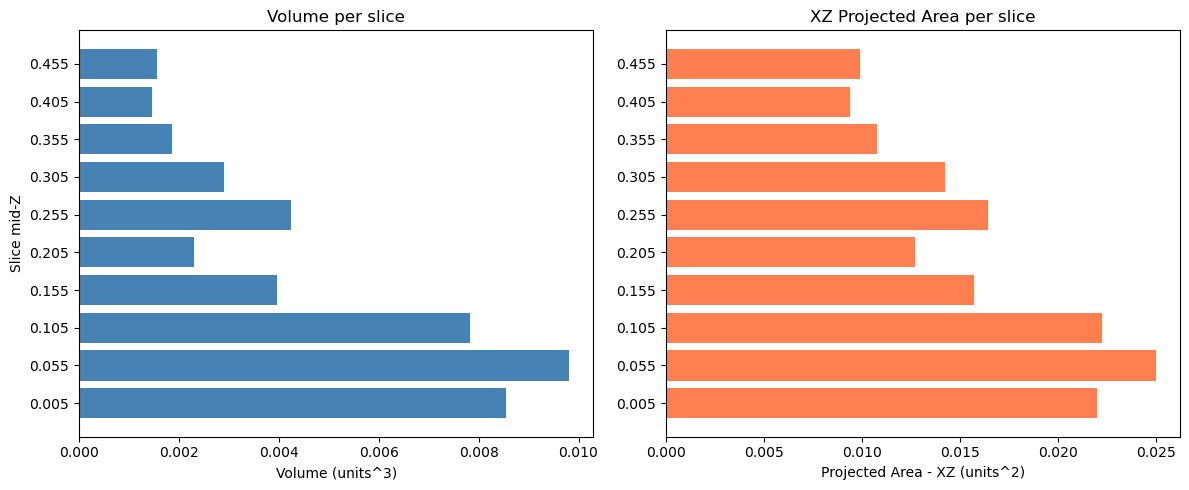

In [11]:
results = analyse_reef_slices("reef_draft.stl", n=10, plot=True)

In [12]:
print(results)

[{'slice_index': 0, 'z_min': np.float64(-0.019999999552965164), 'z_max': np.float64(0.029999999329447746), 'volume': 0.00854135674378377, 'projected_area_xz': 0.021999999128282086}, {'slice_index': 1, 'z_min': np.float64(0.029999999329447746), 'z_max': np.float64(0.07999999821186066), 'volume': 0.009807235154264703, 'projected_area_xz': 0.024988382125392138}, {'slice_index': 2, 'z_min': np.float64(0.07999999821186066), 'z_max': np.float64(0.12999999709427357), 'volume': 0.007820100135190418, 'projected_area_xz': 0.022255879155061064}, {'slice_index': 3, 'z_min': np.float64(0.12999999709427357), 'z_max': np.float64(0.17999999597668648), 'volume': 0.003957484241952172, 'projected_area_xz': 0.015742123217461074}, {'slice_index': 4, 'z_min': np.float64(0.17999999597668648), 'z_max': np.float64(0.2299999948590994), 'volume': 0.002291424155902217, 'projected_area_xz': 0.012697637885764938}, {'slice_index': 5, 'z_min': np.float64(0.2299999948590994), 'z_max': np.float64(0.2799999937415123), '

In [20]:
import numpy as np

volumes = np.array([float((r.get('volume') or 0.0)) for r in results], dtype=float)
projected_areas = np.array([float((r.get('projected_area_xz') or 0.0)) for r in results], dtype=float)
max_slice_z = np.array([float((r.get('z_max') or 0.0)) for r in results], dtype=float)

print(volumes) # in m^3
print(projected_areas) # in m^2
print(max_slice_z)

print(f'The total volume of the structure: {np.sum(volumes)}')

[0.00854136 0.00980724 0.0078201  0.00395748 0.00229142 0.00424953
 0.00289229 0.0018537  0.00145812 0.00156665]
[0.022      0.02498838 0.02225588 0.01574212 0.01269764 0.01643214
 0.0142229  0.0107709  0.00941921 0.00992575]
[0.03       0.08       0.13       0.18       0.22999999 0.27999999
 0.32999999 0.37999999 0.42999999 0.47999999]
The total volume of the structure: 0.04443788748258557


## NONFUNCTIONAL CHATGPT CODE: Code to calculate volumes and areas

Inputs: STL file, number of slices to cut the reef into, the resolution of the technique used to calculate projected area. Areas are projected into the xz plane using this concept (effectively a numerical orthographic projection, according to ChatGPT):

(1) Laying a grid over the XZ plane
(2) Casting rays in the +y direction
(3) Counting how many rays hit the slice
(4) Area = (hit fraction) × (total grid area)

Outputs: array of volumes, array of projected areas.

Note: code written by ChatGPT

In [11]:
import numpy as np
import trimesh

def analyze_stl_slices_xz_projection(stl_file, n_slices, resolution=200):
    mesh = trimesh.load_mesh(stl_file)

    print("Watertight:", mesh.is_watertight)
    print("Bounds:", mesh.bounds)
    print("Number of faces:", len(mesh.faces))

    if not mesh.is_watertight:
        print("Warning: mesh not watertight → volume may be inaccurate")

    z_min, z_max = mesh.bounds[:, 2]
    x_min, x_max = mesh.bounds[:, 0]

    z_levels = np.linspace(z_min, z_max, n_slices + 1)

    slice_volumes = []
    projected_areas = []

    for i in range(n_slices):
        z_lower = z_levels[i]
        z_upper = z_levels[i + 1]

        # Clip slice using planes
        sliced = mesh.slice_plane(
            plane_origin=[0, 0, z_lower],
            plane_normal=[0, 0, -1]
        )
        if sliced is None:
            slice_volumes.append(0)
            projected_areas.append(0)
            continue

        sliced = sliced.slice_plane(
            plane_origin=[0, 0, z_upper],
            plane_normal=[0, 0, 1]
        )
        if sliced is None or len(sliced.faces) == 0:
            slice_volumes.append(0)
            projected_areas.append(0)
            continue

        # ---- Volume ----
        slice_volumes.append(sliced.volume)

        # ---- Orthographic Projection onto XZ ----
        # Define grid in XZ
        x = np.linspace(x_min, x_max, resolution)
        z = np.linspace(z_lower, z_upper, resolution)

        xx, zz = np.meshgrid(x, z)
        points = np.column_stack([xx.ravel(), 
                                  np.full(xx.size, mesh.bounds[0][1] - 1.0),  # start before mesh
                                  zz.ravel()])

        # Rays in +y direction
        directions = np.tile([0, 1, 0], (points.shape[0], 1))

        # Ray intersection
        locations, index_ray, index_tri = sliced.ray.intersects_location(
            ray_origins=points,
            ray_directions=directions
        )

        # Unique rays that hit something
        hit_rays = np.unique(index_ray)

        # Area calculation
        dx = (x_max - x_min) / (resolution - 1)
        dz = (z_upper - z_lower) / (resolution - 1)

        area = len(hit_rays) * dx * dz
        projected_areas.append(area)

    return np.array(slice_volumes), np.array(projected_areas)

### Test code

In [13]:
stl_file = 'test_cube.stl'
n_slices = 10
resolution = 200

volumes, areas = analyze_stl_slices_xz_projection(stl_file, n_slices, resolution)

for i in range(len(volumes)):
    print(f"Slice {i}: Volume={volumes[i]:.3f}, Projected Area={areas[i]:.3f}")

Watertight: True
Bounds: [[-9.02056208e-17  0.00000000e+00  0.00000000e+00]
 [ 5.00000000e-01  5.00000000e-01  5.00000000e-01]]
Number of faces: 12
Slice 0: Volume=0.000, Projected Area=0.000
Slice 1: Volume=0.000, Projected Area=0.000
Slice 2: Volume=0.000, Projected Area=0.000
Slice 3: Volume=0.000, Projected Area=0.000
Slice 4: Volume=0.000, Projected Area=0.000
Slice 5: Volume=0.000, Projected Area=0.000
Slice 6: Volume=0.000, Projected Area=0.000
Slice 7: Volume=0.000, Projected Area=0.000
Slice 8: Volume=0.000, Projected Area=0.000
Slice 9: Volume=0.000, Projected Area=0.000
